In [1]:
import pandas as pd
import numpy as np
import scipy
from scipy import stats
from scipy.stats import binom, poisson, norm, t

In [2]:
df = pd.read_excel('/content/drive/MyDrive/Advanced_Analytics_using_statistics/CDAC_DataBook.xlsx', sheet_name='faithful')

In [3]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [4]:
norm.cdf(43,45,2.8)

np.float64(0.2375252620269765)

In [5]:
z = (43-45)/2.8

In [6]:
z

-0.7142857142857143

In [7]:
norm.cdf(z,0,1)

np.float64(0.2375252620269765)

In [8]:
z = (24-25.3)/1.8
norm.cdf(z)

np.float64(0.23507893142883468)

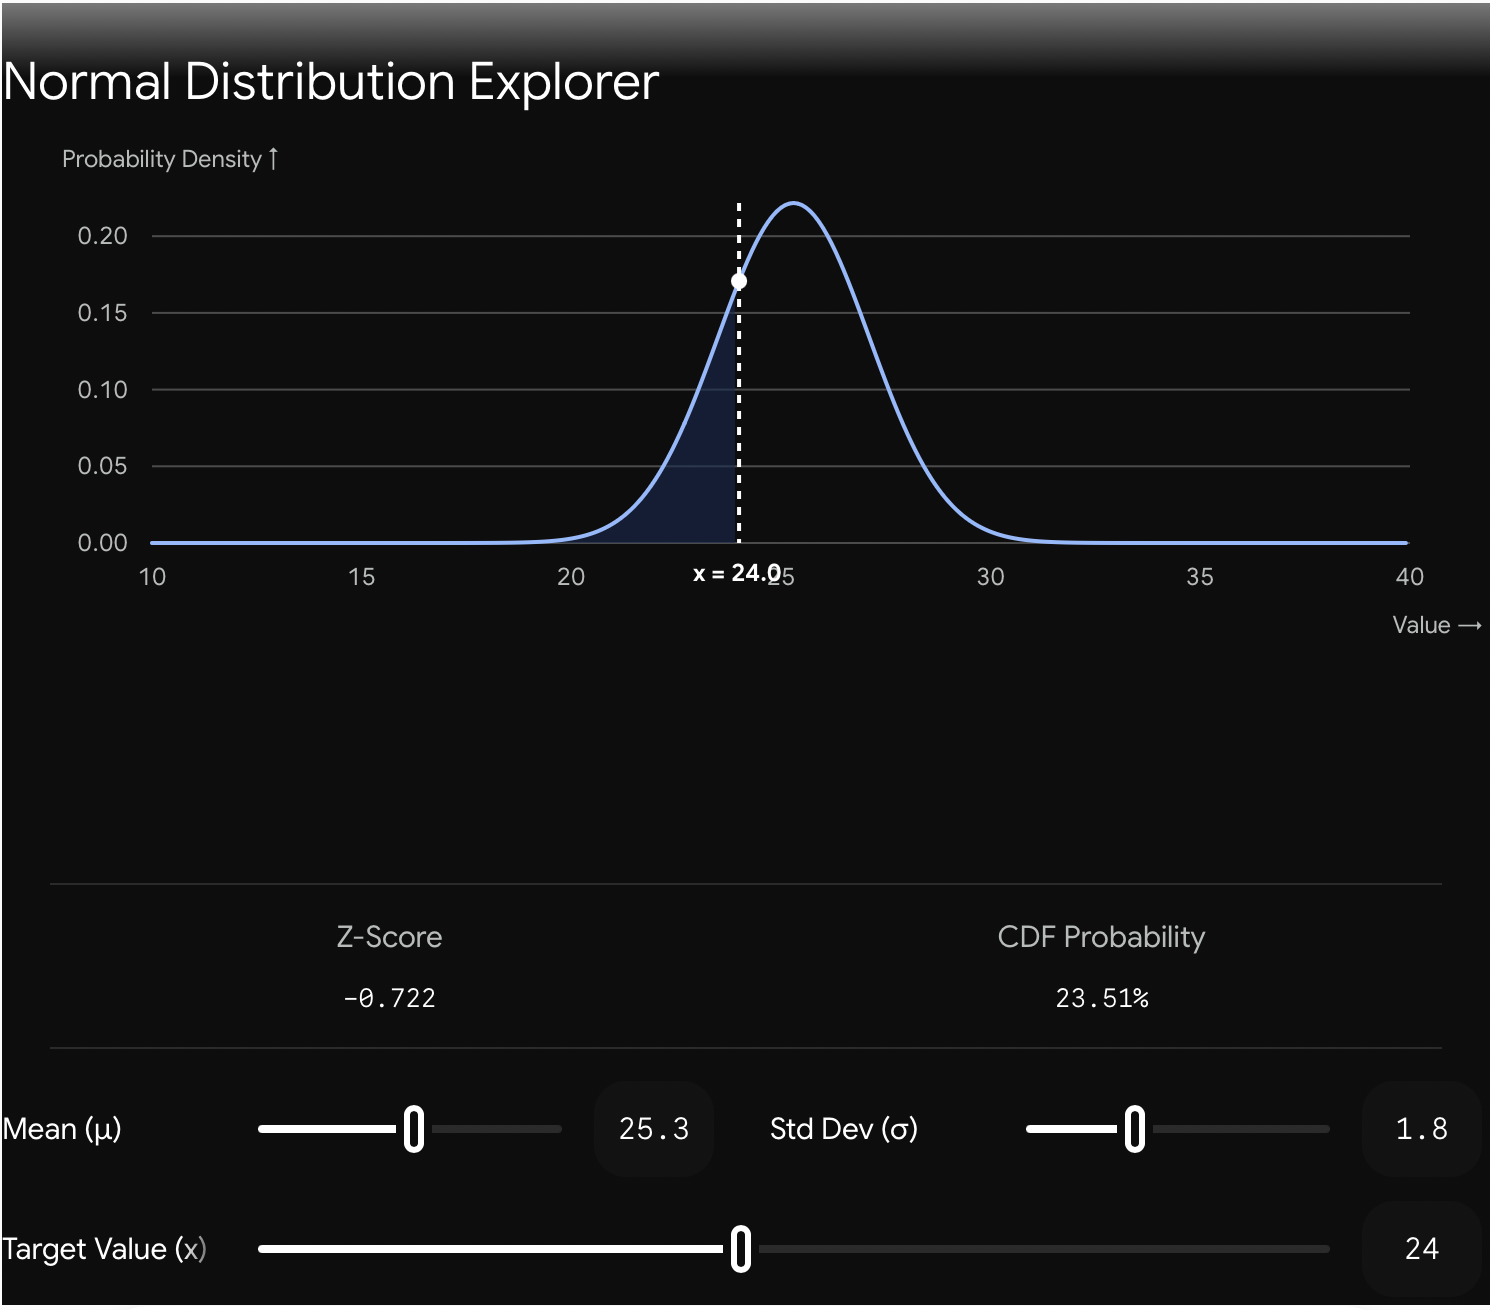

In [9]:
t.cdf(z,1499)

np.float64(0.2351352562574976)

In [10]:
365*84

30660

In [11]:
8760/200
# Answer >> 43.8 (hour/incident)

43.8

In [12]:
1/43.8

0.022831050228310504

In [13]:
from scipy.stats import expon
expon.cdf(100,scale=43.8)

np.float64(0.898032895521957)

In [14]:
expon.cdf(100,scale=43.8)

np.float64(0.898032895521957)

In [15]:
24/80

0.3

In [16]:
df1 = pd.read_excel('/content/drive/MyDrive/Advanced_Analytics_using_statistics/data1.xlsx')

In [17]:
df1.head()

,Category
0,C
1,D
2,C
3,A
4,B


In [18]:
df1.Category.isnull().sum()

np.int64(80)

In [19]:
np.where(df1.Category.isnull())

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [20]:
df1.Category.value_counts()

,count
Category,
B,113
A,112
C,101
D,94


In [21]:
props = pd.DataFrame(df1.Category.value_counts())

In [22]:
props.head()

,count
Category,
B,113
A,112
C,101
D,94


In [23]:
props['proportion'] = props['count']/sum(props['count'])

In [24]:
props

,count,proportion
Category,,
B,113,0.269048
A,112,0.266667
C,101,0.240476
D,94,0.223810


In [25]:
random_values= np.random.choice(['A','B','C','D'], size=80,p=props.proportion)

In [26]:
props

,count,proportion
Category,,
B,113,0.269048
A,112,0.266667
C,101,0.240476
D,94,0.223810


In [27]:
ind = np.where(df1.Category.isnull())

In [28]:
df1.loc[ind[0],'Category'] = random_values

In [29]:
df1.Category.isnull().sum()

np.int64(0)

In [30]:
df1.head(15)

,Category
0,C
1,D
2,C
3,A
4,B
5,A
6,B
7,C
8,D
9,B


In [32]:
df.Quantity.fillna(df.Quantity.median())

AttributeError: 'DataFrame' object has no attribute 'Quantity'

In [ ]:
df1.Continous_value.fillna(df1.Continous_value.median())

In [ ]:
df1.info()

***Step 1: Identify the Core Data (The Box)***\
Before doing any math, you pull three key percentiles from your dataset to build the main "box":\
Q1 (25th Percentile): 70\
Q2 (Median): 90\
Q3 (75th Percentile): 130\
**Step 2: Calculate the Interquartile Range (IQR)**\
The very first line on the board calculates the spread of the middle 50% of the data.\
IQR=Q3−Q1\
IQR=130−70=60\
**Step 3: Calculate the Invisible Fences**\
Next, the board calculates the Upper Fence (UF) and Lower Fence (LF).\These are the mathematical boundaries; anything outside of them is declared an outlier.\
The Upper Fence (UF):\
UF=Q3+1.5×IQR\
UF=130+(1.5×60)\
UF=130+90=220\
The Lower Fence (LF):\
LF=Q1−1.5×IQR\
LF=70−(1.5×60)\
LF=70−90=−20\
(Note: Your professor wrote "-20 or 0". This happens a lot in real-world data like salaries or quantities where you physically cannot have a negative number, so the boundary just stops at 0).\
**Step 4: Draw the Whiskers**\
Look at the text pointing to the ends of the horizontal lines (whiskers) at 40 and 180. This is a highly testable concept!\
Lower Whisker: It does not go all the way down to the -20 fence. It stops at 40, because 40 is the "Lowest value between Q1 & LF" (the lowest actual data point that isn't an outlier).\
Upper Whisker: It stops at 180, because 180 is the "Highest value between Q3 & UF" (the highest actual data point before crossing the fence).\
**Step 5: Plot the Outliers**\
Look at the far right side of the drawing. There is a dot plotted past the 220 line with stars around it and a box labeled OUTLIER. \Because this specific data point is greater than the Upper Fence of 220, it gets plotted as an individual dot rather than being included in the whisker.\
To help cement this specific calculation, here is an interactive widget loaded with your whiteboard's exact numbers. You can change Q1, the Median, or Q3 and watch how the math for the fences updates automatically!\



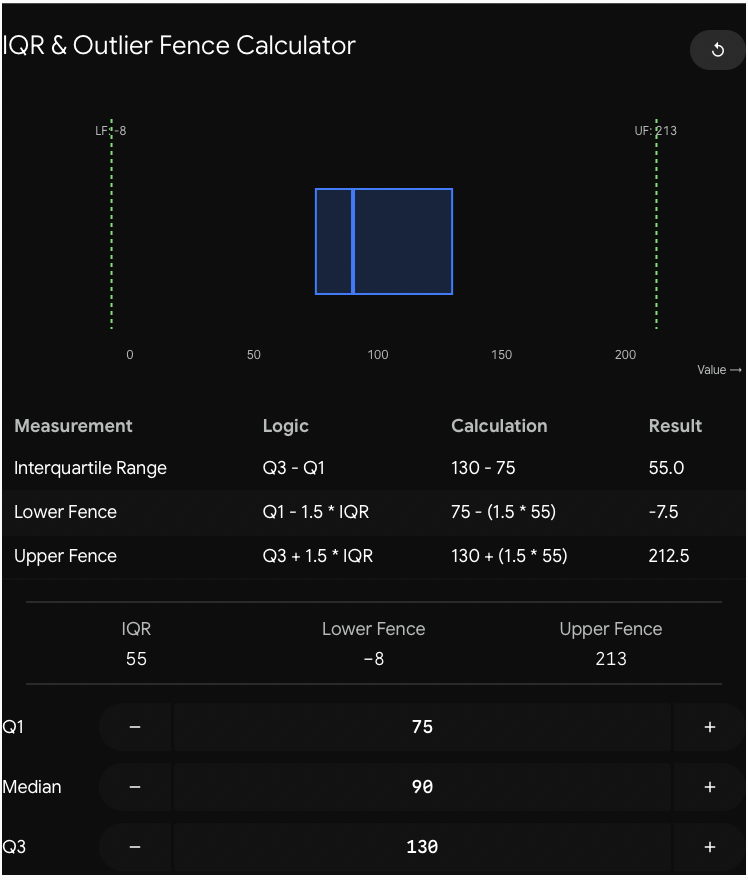

In [33]:
df3 = pd.read_excel('/content/drive/MyDrive/Advanced_Analytics_using_statistics/data2.xlsx')

In [34]:
df3.head()

,Category,Continuous_Value
0,C,-4008.098297
1,D,-3887.888132
2,NaN,-3712.188312
3,C,-3416.823821
4,D,-5845.073897


In [35]:
q3 = np.percentile(df3.values)

TypeError: percentile() missing 1 required positional argument: 'q'

In [ ]:
df3.tail()


04:30


In [36]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title,xlabel,ylabel

In [37]:
states = ['KA','MH','AP','MP','UP']
Counts = [40,35,50,20,25]

<BarContainer object of 5 artists>

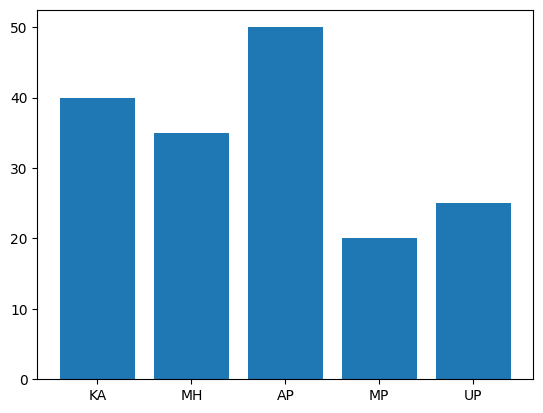

In [38]:
plt.bar(states,Counts)

In [39]:
df4 = pd.read_excel('/content/drive/MyDrive/Advanced_Analytics_using_statistics/CDAC_DataBook.xlsx', sheet_name='ERPData')

In [40]:
df4.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [41]:
df41 = df4.MaterialID.value_counts()

<BarContainer object of 6 artists>

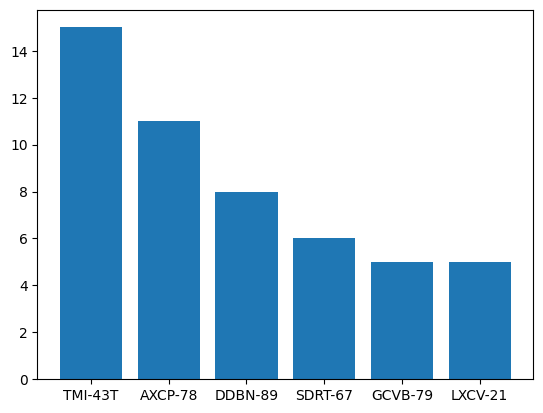

In [42]:
plt.bar(df41.index,df41)

In [43]:
df42 = df4.Location.value_counts()

<BarContainer object of 5 artists>

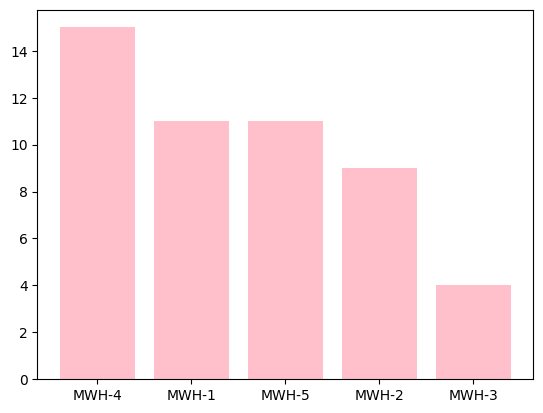

In [44]:
plt.bar(df42.index,df42,facecolor='pink')

<BarContainer object of 6 artists>

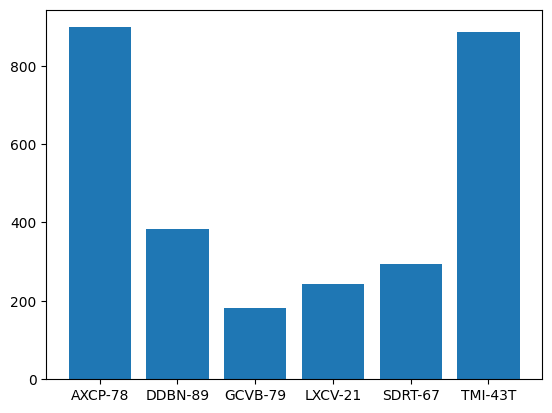

In [45]:
grp1 = df4.groupby('MaterialID')
df43 = grp1.Quantity.agg('sum')
plt.bar(df43.index,df43)

<BarContainer object of 6 artists>

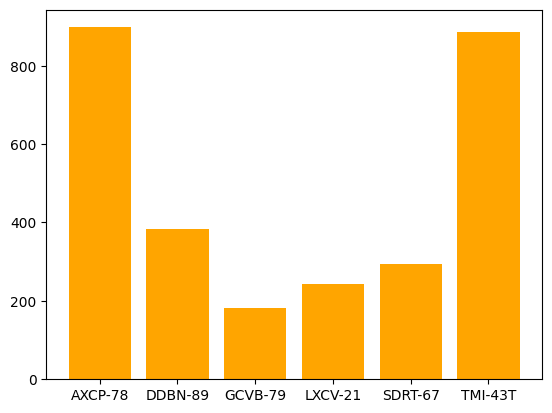

In [46]:
plt.bar(df43.index,df43,facecolor='orange')

In [47]:
df4.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [48]:
df44 = pd.crosstab(df4.Location,df4.MaterialID)

In [49]:
df44

MaterialID,AXCP-78,DDBN-89,GCVB-79,LXCV-21,SDRT-67,TMI-43T
Location,,,,,,
MWH-1,5,3,0,0,2,1
MWH-2,1,1,4,1,1,1
MWH-3,1,1,0,1,0,1
MWH-4,1,2,0,0,1,11
MWH-5,3,1,1,3,2,1


<Axes: xlabel='Location'>

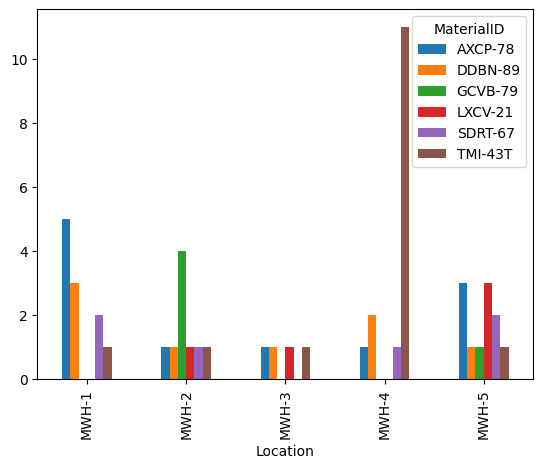

In [50]:
df44.plot(kind='bar')


<Axes: >

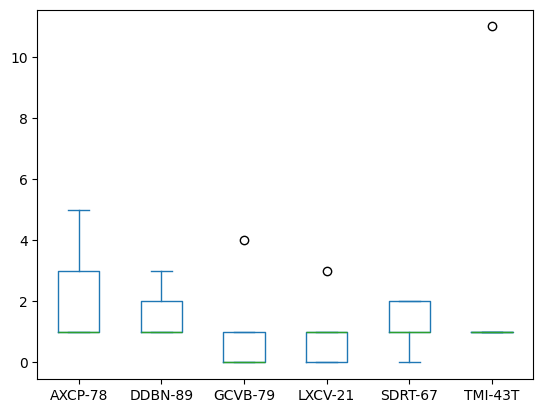

In [51]:
df44.plot(kind='box')

<Axes: ylabel='Density'>

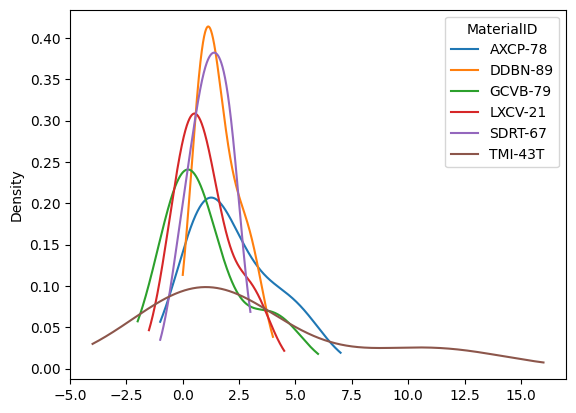

In [52]:
df44.plot(kind='density') # Valid plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

In [65]:
df4.columns.values

array(['MaterialID', 'Location', 'Quantity'], dtype=object)

<Axes: ylabel='Location'>

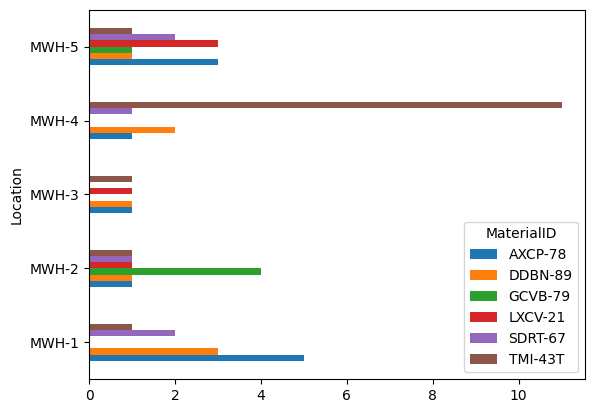

In [53]:
1df44.plot(kind='barh') # Valid plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

<Axes: xlabel='Location'>

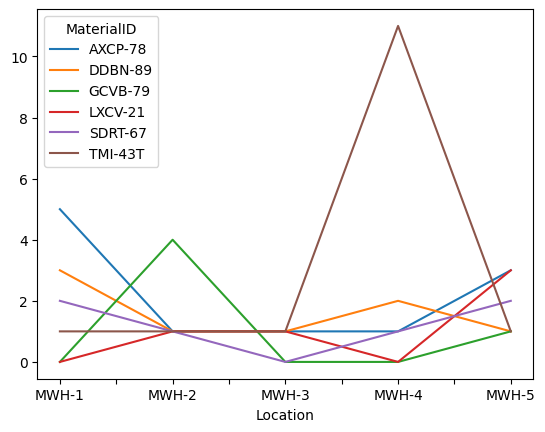

In [54]:
df44.plot(kind='line') # Valid plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

<Axes: ylabel='Frequency'>

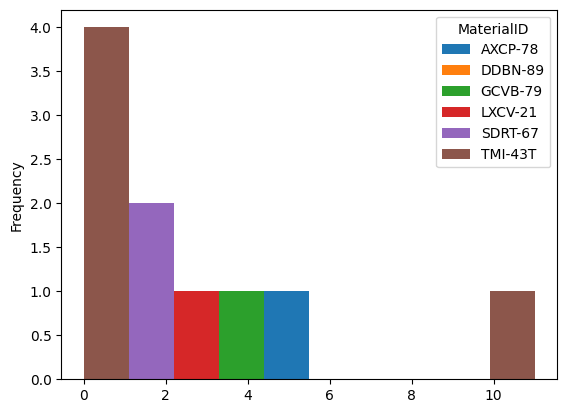

In [55]:
df44.plot(kind='hist')

array([<Axes: ylabel='AXCP-78'>, <Axes: ylabel='DDBN-89'>,
       <Axes: ylabel='GCVB-79'>, <Axes: ylabel='LXCV-21'>,
       <Axes: ylabel='SDRT-67'>, <Axes: ylabel='TMI-43T'>], dtype=object)

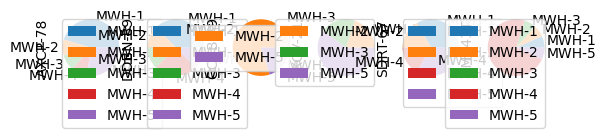

In [56]:
df44.plot(kind='pie',subplots=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x78f99ed5bbc0>,
 'caps': [<matplotlib.lines.Line2D at 0x78f99ed8c110>,
 'boxes': [<matplotlib.lines.Line2D at 0x78f9a2806d80>],
 'medians': [<matplotlib.lines.Line2D at 0x78f99ed8c6e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x78f99ed8c8c0>],
 'means': []}

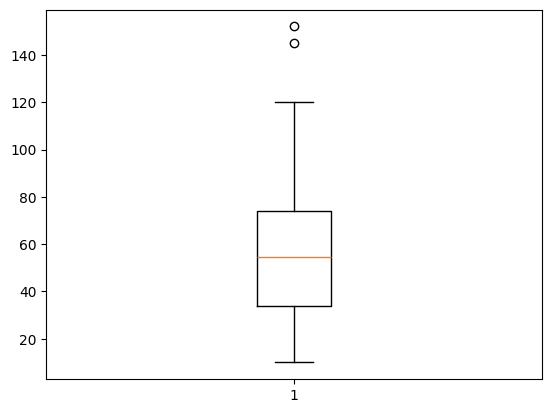

In [57]:
plt.boxplot(df4.Quantity)

{'whiskers': [<matplotlib.lines.Line2D at 0x78f99edc20f0>,
 'caps': [<matplotlib.lines.Line2D at 0x78f99edc2600>,
 'boxes': [<matplotlib.lines.Line2D at 0x78f99edc1e50>,
 'medians': [<matplotlib.lines.Line2D at 0x78f99edc2b40>,
 'fliers': [<matplotlib.lines.Line2D at 0x78f99edc2e40>,
 'means': []}

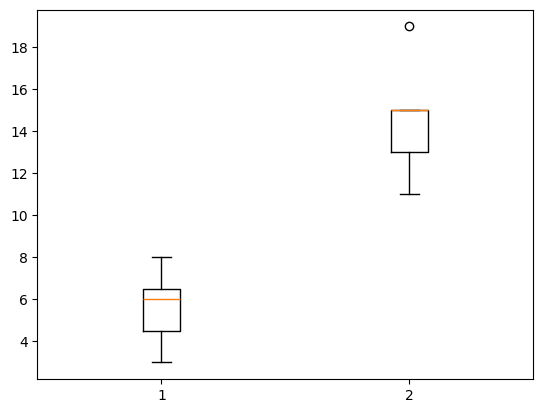

In [58]:
male_sal = [4,6,5,3,7,6,8]
female_sal = [11,15,13,19,15]
plt.boxplot([male_sal,female_sal])